In [20]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI
import h5py
import pandas as pd
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.optimize import minimize


In [21]:
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_spring_fine_V4.dat"
exp_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\002\34224_03CB_02_002_001_01_Decay1.h5m"

lookback_window = 5.0      # seconden vóór decay-start waarin we de amplitude zoeken
quiet_window_end = 12.0     # rustige periode eindigt 12 s vóór decay-start
quiet_window_length = 50.0


In [22]:
with h5py.File(exp_path, "r") as f:
    # gefilterd
    t_filt = f["FittedSignals/time"][:]
    z_filt = f["FittedSignals/PITCH decay fit"][:]

    # ongefilterd
    t_unfiltered = f["UnfilteredSignals/time"][:]
    z_unfiltered = f["UnfilteredSignals/PITCH (unfiltered)"][:]



In [23]:

# --------------------------------------------------
# 1. decay-start van filtered cropped signal
#    dit blijft handig als globale referentie
# --------------------------------------------------
t_decay_start_guess = t_filt[0]

# --------------------------------------------------
# 2. rustige periode kiezen in ONGEFILTERD signaal
# --------------------------------------------------
quiet_start = t_decay_start_guess - quiet_window_end - quiet_window_length
quiet_end = t_decay_start_guess - quiet_window_end

mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

if not np.any(mask_quiet):
    raise ValueError("Geen data gevonden in de gekozen rustige periode.")

z_eq = np.mean(z_unfiltered[mask_quiet])

# --------------------------------------------------
# 3. zoek initiële amplitude in ONGEFILTERD signaal
# --------------------------------------------------
search_start = t_decay_start_guess - lookback_window
search_end = t_decay_start_guess

mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

if not np.any(mask_search):
    raise ValueError("Geen data gevonden in zoekvenster vóór decay-start.")

t_search = t_unfiltered[mask_search]
z_search = z_unfiltered[mask_search]

deviation = z_search - z_eq
idx_local = np.argmax(np.abs(deviation))

t_init = t_search[idx_local]
z_init = z_search[idx_local]
A0_signed = z_init - z_eq
A0 = np.abs(A0_signed)

# --------------------------------------------------
# 4. zoek in GEFILTERD signaal de eerste piek ná t_init
# --------------------------------------------------
mask_after_init = t_filt > t_init
t_after = t_filt[mask_after_init]
z_after = z_filt[mask_after_init]

if len(t_after) == 0:
    raise ValueError("Geen gefilterde data gevonden na t_init.")

# zelfde teken als de initiële amplitude volgen
if A0_signed >= 0:
    peaks, _ = find_peaks(z_after)
else:
    peaks, _ = find_peaks(-z_after)

if len(peaks) == 0:
    raise ValueError("Geen pieken gevonden in gefilterde signaal na t_init.")

idx_first_peak_local = peaks[0]
t_decay_start = t_after[idx_first_peak_local]
z_decay_start = z_after[idx_first_peak_local]

# --------------------------------------------------
# 5. decay-signaal maken vanaf die eerste piek
# --------------------------------------------------
mask_decay = t_filt >= t_decay_start
t_decay = t_filt[mask_decay] - t_decay_start
z_decay = z_filt[mask_decay] - z_eq

print(f"Decay start guess (cropped) = {t_decay_start_guess:.3f} s")
print(f"Quiet window                = [{quiet_start:.3f}, {quiet_end:.3f}] s")
print(f"Equilibrium level z_eq      = {z_eq:.6f} m")
print(f"Search window               = [{search_start:.3f}, {search_end:.3f}] s")
print(f"Initial extreme (unfilt) t  = {t_init:.3f} s")
print(f"Initial extreme (unfilt) roll  = {z_init:.6f} degree")
print(f"Initial DEGREE       = {A0:.6f} rad")
print(f"Signed DEGREE            = {A0_signed:.6f} degree")
print(f"Decay start (filtered peak) = {t_decay_start:.3f} s")
print(f"Decay start DEGREE               = {z_decay_start:.6f} degree")

Decay start guess (cropped) = 357.116 s
Quiet window                = [295.116, 345.116] s
Equilibrium level z_eq      = -0.055629 m
Search window               = [352.116, 357.116] s
Initial extreme (unfilt) t  = 355.368 s
Initial extreme (unfilt) roll  = -6.104080 degree
Initial DEGREE       = 6.048451 rad
Signed DEGREE            = -6.048451 degree
Decay start (filtered peak) = 362.673 s
Decay start DEGREE               = -4.936140 degree


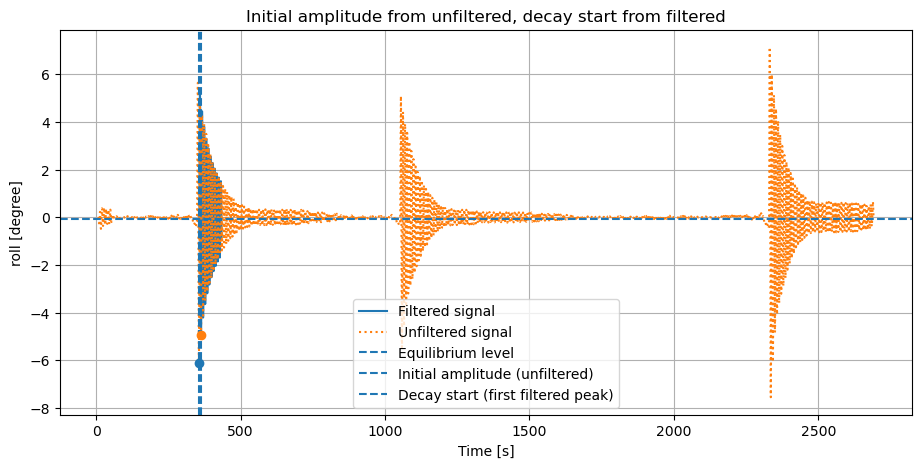

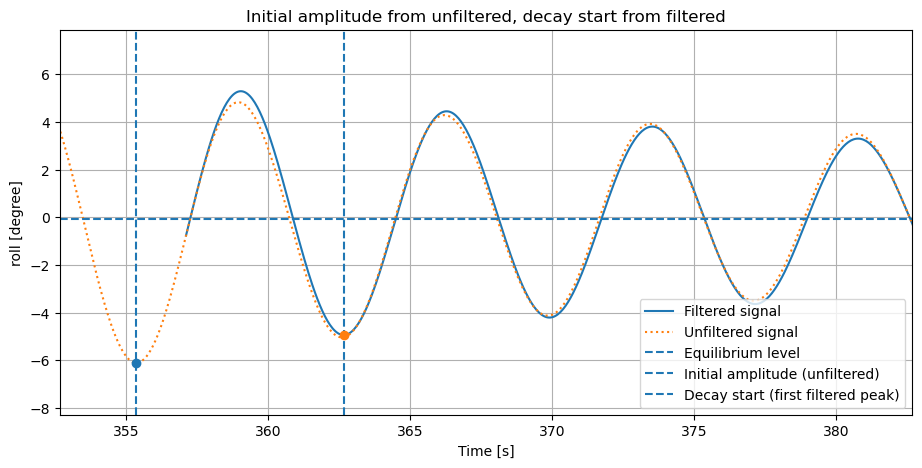

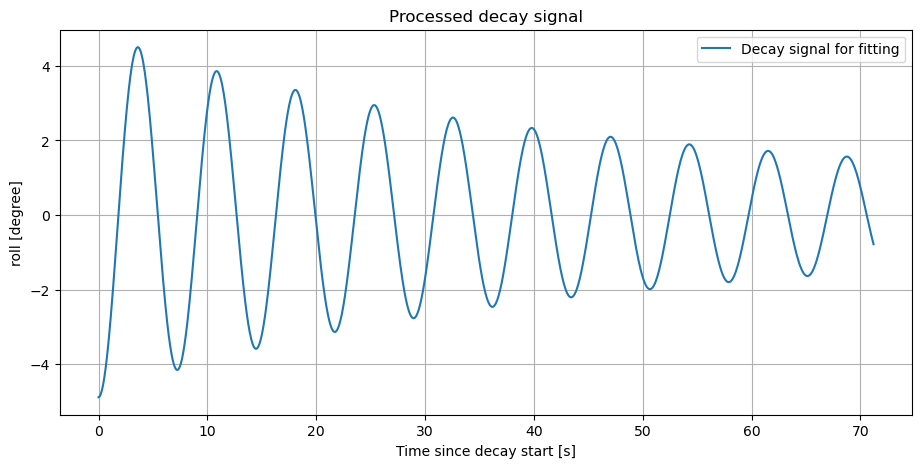

z_init is -6.104080 degree
z_decay_start is -4.936140 degree


In [24]:
plt.figure(figsize=(11, 5))
plt.plot(t_filt, z_filt, label="Filtered signal")
plt.plot(t_unfiltered, z_unfiltered, ":", label="Unfiltered signal")
plt.axhline(z_eq, linestyle="--", label="Equilibrium level")
plt.axvline(t_init, linestyle="--", label="Initial amplitude (unfiltered)")
plt.axvline(t_decay_start, linestyle="--", label="Decay start (first filtered peak)")
plt.scatter([t_init], [z_init], zorder=5)
plt.scatter([t_decay_start], [z_decay_start], zorder=5)
plt.xlabel("Time [s]")
plt.ylabel("roll [degree]")
# plt.xlim(t_decay_start - 10, t_decay_start + 20)
plt.title("Initial amplitude from unfiltered, decay start from filtered")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(t_filt, z_filt, label="Filtered signal")
plt.plot(t_unfiltered, z_unfiltered, ":", label="Unfiltered signal")
plt.axhline(z_eq, linestyle="--", label="Equilibrium level")
plt.axvline(t_init, linestyle="--", label="Initial amplitude (unfiltered)")
plt.axvline(t_decay_start, linestyle="--", label="Decay start (first filtered peak)")
plt.scatter([t_init], [z_init], zorder=5)
plt.scatter([t_decay_start], [z_decay_start], zorder=5)
plt.xlabel("Time [s]")
plt.ylabel("roll [degree]")
plt.xlim(t_decay_start - 10, t_decay_start + 20)
plt.title("Initial amplitude from unfiltered, decay start from filtered")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(t_decay, z_decay, label="Decay signal for fitting")
plt.xlabel("Time since decay start [s]")
plt.ylabel("roll [degree]")
plt.title("Processed decay signal")
plt.grid(True)
plt.legend()
plt.show()

print(f'z_init is {z_init:.6f} degree')
print(f'z_decay_start is {z_decay_start:.6f} degree')

In [25]:
model = OrcFxAPI.Model(model_path)
constraint = model["decay_constraint"]
floaters = model["floaters"]
floatertype = model["Floatertype"]


In [26]:
constraint.InFrameInitialZ = 0
constraint.InFrameInitialX = 0
constraint.InFrameInitialY = 0
constraint.InFrameInitialAzimuth = 0
constraint.InFrameInitialDeclination = A0
constraint.InFrameInitialGamma = 0

floatertype.OtherDampingLinearCoeffx = 0 #surge
floatertype.OtherDampingLinearCoeffy = 0 #sway
floatertype.OtherDampingLinearCoeffz  = 0#heav
floatertype.OtherDampingLinearCoeffRx = 0 #roll
floatertype.OtherDampingLinearCoeffRy = 0 #pitch
floatertype.OtherDampingLinearCoeffRz = 0 #yaw

floatertype.OtherDampingQuadraticCoeffx = 0 #surge
floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
floatertype.OtherDampingQuadraticCoeffz = 0 #heav
floatertype.OtherDampingQuadraticCoeffRx = 0#roll
floatertype.OtherDampingQuadraticCoeffRy = 0 #pitch
floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw

print(constraint.InFrameInitialZ)

0.0


In [27]:
model.RunSimulation()
print("Simulatie klaar.")

Simulatie klaar.


In [28]:
t_sim = model.general.TimeHistory("Time")
z_sim = floaters.TimeHistory("rotation 2")


z_sim_eq = np.mean(z_sim[-200:])
z_sim_corr = z_sim - z_sim_eq

# --------------------------------------------------
# 2. pieken zoeken van hetzelfde teken als A0_signed
# --------------------------------------------------
if A0_signed >= 0:
    sim_peaks, _ = find_peaks(z_sim_corr)
else:
    sim_peaks, _ = find_peaks(-z_sim_corr)

if len(sim_peaks) < 2:
    raise ValueError("Niet genoeg pieken gevonden om de initiële amplitude en eerste vrije piek te onderscheiden.")

# --------------------------------------------------
# 3. eerste piek = initiële amplitude
#    tweede piek = eerste vrije piek
# --------------------------------------------------
idx_init_peak = sim_peaks[0]
idx_first_free_peak = sim_peaks[1]

t_init_peak = t_sim[idx_init_peak]
z_init_peak = z_sim_corr[idx_init_peak]

t_first_free_peak = t_sim[idx_first_free_peak]
z_first_free_peak = z_sim_corr[idx_first_free_peak]

print(f"Sim equilibrium level      = {z_sim_eq:.6f} m")
print(f"Initial imposed peak at t  = {t_init_peak:.6f} s")
print(f"Initial imposed peak z     = {z_init_peak:.6f} m")
print(f"First free peak at t       = {t_first_free_peak:.6f} s")
print(f"First free peak z          = {z_first_free_peak:.6f} m")

# --------------------------------------------------
# 4. hele simulatie verschuiven zodat eerste vrije piek t=0 wordt
#    en initiële amplitude-piek wegvalt
# --------------------------------------------------
mask_sim_decay = t_sim >= t_first_free_peak
t_sim_decay = t_sim[mask_sim_decay] - t_first_free_peak
z_sim_decay = z_sim_corr[mask_sim_decay]

Sim equilibrium level      = 0.280893 m
Initial imposed peak at t  = -4.400000 s
Initial imposed peak z     = -6.093470 m
First free peak at t       = 2.600000 s
First free peak z          = -5.830901 m


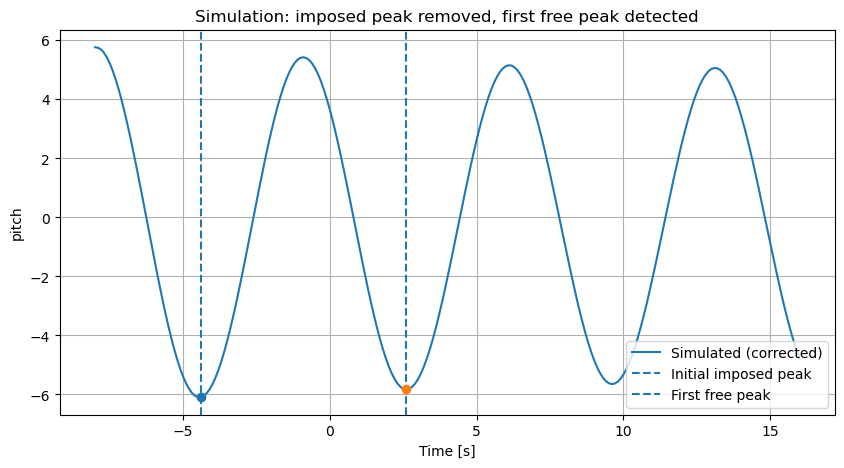

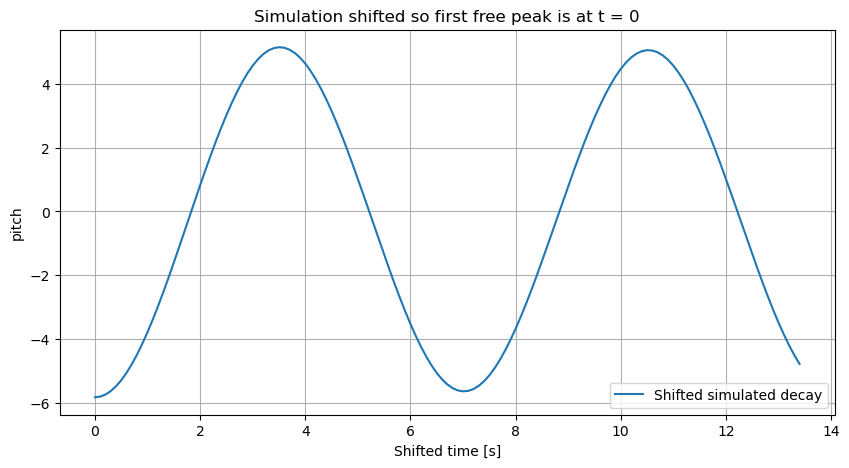

In [29]:
plt.figure(figsize=(10, 5))
plt.plot(t_sim, z_sim_corr, label="Simulated (corrected)")
plt.axvline(t_init_peak, linestyle="--", label="Initial imposed peak")
plt.axvline(t_first_free_peak, linestyle="--", label="First free peak")
plt.scatter([t_init_peak], [z_init_peak], zorder=5)
plt.scatter([t_first_free_peak], [z_first_free_peak], zorder=5)
plt.xlabel("Time [s]")
plt.ylabel("pitch")
plt.title("Simulation: imposed peak removed, first free peak detected")
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------
# 6. plot verschoven decay-signaal
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(t_sim_decay, z_sim_decay, label="Shifted simulated decay")
plt.xlabel("Shifted time [s]")
plt.ylabel("pitch")
plt.title("Simulation shifted so first free peak is at t = 0")
plt.grid(True)
plt.legend()
plt.show()

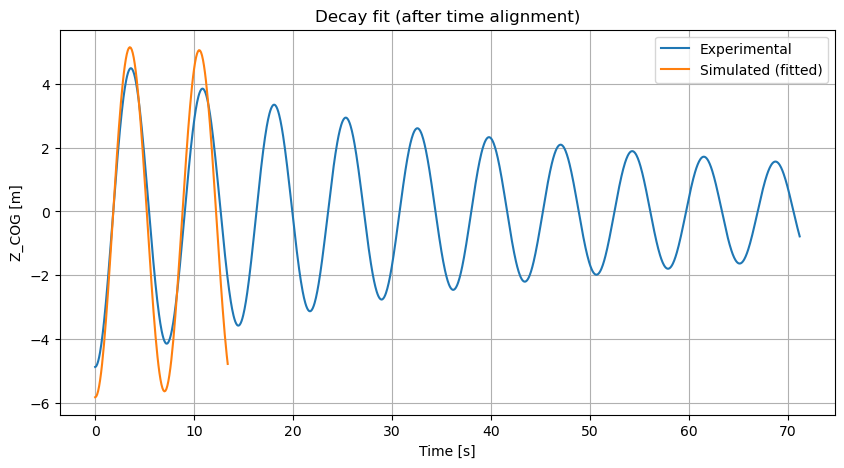

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(t_decay, z_decay, label="Experimental")
plt.plot(t_sim_decay, z_sim_decay, label="Simulated (fitted)")

plt.xlabel("Time [s]")
plt.ylabel("Z_COG [m]")
plt.title("Decay fit (after time alignment)")
plt.grid(True)
plt.legend()
plt.show()

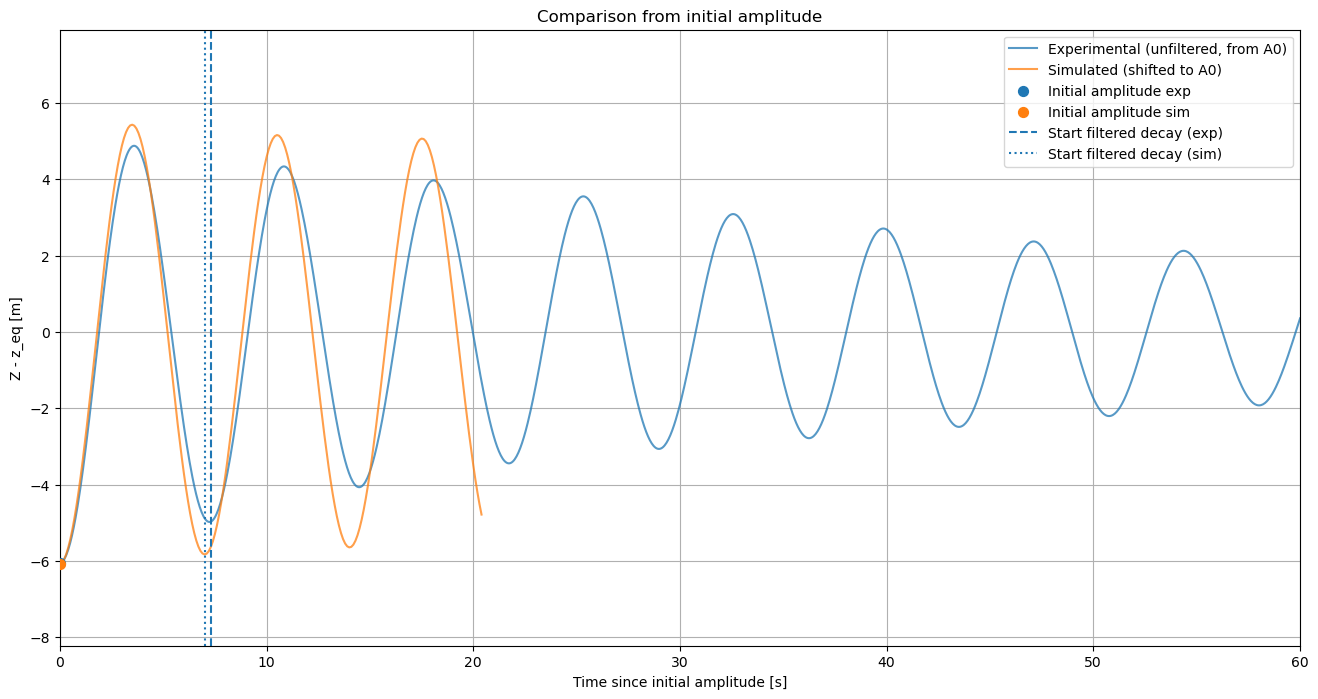

In [31]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# EXPERIMENT vanaf initiële amplitude (ongefilterd)
# --------------------------------------------------
mask_exp_init = t_unfiltered >= t_init
t_exp_init = t_unfiltered[mask_exp_init] - t_init
z_exp_init = z_unfiltered[mask_exp_init] - z_eq

# punt van initiële amplitude in experimentele plot
t_exp_A0_plot = 0.0
z_exp_A0_plot = z_init - z_eq

# verticale lijn: start van decay-fit in experimentele tijd
t_decay_line_exp = t_decay_start - t_init

# --------------------------------------------------
# SIMULATIE corrigeren rond eigen evenwicht
# --------------------------------------------------
z_sim_eq = np.mean(z_sim[-200:])
z_sim_corr = z_sim - z_sim_eq

# --------------------------------------------------
# INITIËLE amplitude-piek van simulatie bepalen
# zelfde teken als A0_signed
# --------------------------------------------------
if A0_signed >= 0:
    sim_peaks, _ = find_peaks(z_sim_corr)
else:
    sim_peaks, _ = find_peaks(-z_sim_corr)

if len(sim_peaks) == 0:
    raise ValueError("Geen initiële piek gevonden in simulatie.")

# eerste piek = opgelegde initiële amplitude
idx_init_peak_sim = sim_peaks[0]
t_init_peak_sim = t_sim[idx_init_peak_sim]
z_init_peak_sim = z_sim_corr[idx_init_peak_sim]

# --------------------------------------------------
# SIMULATIE verschuiven zodat initiële amplitude op t=0 ligt
# --------------------------------------------------
t_sim_shifted_A0 = t_sim - t_init_peak_sim

# alleen stuk vanaf initiële amplitude tonen
mask_sim_init = (t_sim_shifted_A0 >= 0) & (t_sim_shifted_A0 <= 60.0)
t_sim_init = t_sim_shifted_A0[mask_sim_init]
z_sim_init = z_sim_corr[mask_sim_init]

# punt van initiële amplitude in geshiftte sim-plot
t_sim_A0_plot = 0.0
z_sim_A0_plot = z_init_peak_sim

# verticale lijn voor eerste vrije piek in simulatie
# als je deze eerder al bepaald hebt:
# t_first_free_peak = ...
t_decay_line_sim = t_first_free_peak - t_init_peak_sim

# --------------------------------------------------
# PLOT
# --------------------------------------------------
plt.figure(figsize=(16, 8))

plt.plot(t_exp_init, z_exp_init, label="Experimental (unfiltered, from A0)", alpha=0.75)
plt.plot(t_sim_init, z_sim_init, label="Simulated (shifted to A0)", alpha=0.75)

# punten op initiële amplitude
plt.scatter(t_exp_A0_plot, z_exp_A0_plot, s=50, zorder=5, label="Initial amplitude exp")
plt.scatter(t_sim_A0_plot, z_sim_A0_plot, s=50, zorder=5, label="Initial amplitude sim")

# verticale lijn vanaf waar filtered decay bekeken wordt
plt.axvline(t_decay_line_exp, linestyle="--", linewidth=1.5, label="Start filtered decay (exp)")
plt.axvline(t_decay_line_sim, linestyle=":", linewidth=1.5, label="Start filtered decay (sim)")

plt.xlim(0, 60)
plt.xlabel("Time since initial amplitude [s]")
plt.ylabel("Z - z_eq [m]")
plt.title("Comparison from initial amplitude")
plt.grid(True)
plt.legend()
plt.show()

In [32]:
# -----------------------------
# PIEKEN EN DALEN ZOEKEN
# -----------------------------
peaks_exp, _ = find_peaks(z_exp_init)
troughs_exp, _ = find_peaks(-z_exp_init)

peaks_sim, _ = find_peaks(z_sim_init)
troughs_sim, _ = find_peaks(-z_sim_init)

# -----------------------------
# PERIODES OP BASIS VAN PIEKEN
# -----------------------------
T_exp_peaks = np.diff(t_exp_init[peaks_exp])
T_sim_peaks = np.diff(t_sim_init[peaks_sim])

# -----------------------------
# PERIODES OP BASIS VAN DALEN
# -----------------------------
T_exp_troughs = np.diff(t_exp_init[troughs_exp])
T_sim_troughs = np.diff(t_sim_init[troughs_sim])

# -----------------------------
# DATAFRAMES
# -----------------------------
df_peaks_exp = pd.DataFrame({
    "t_peak_exp [s]": t_exp_init[peaks_exp],
    "z_peak_exp [m]": z_exp_init[peaks_exp]
})

df_peaks_sim = pd.DataFrame({
    "t_peak_sim [s]": t_sim_init[peaks_sim],
    "z_peak_sim [m]": z_sim_init[peaks_sim]
})

df_troughs_exp = pd.DataFrame({
    "t_trough_exp [s]": t_exp_init[troughs_exp],
    "z_trough_exp [m]": z_exp_init[troughs_exp]
})

df_troughs_sim = pd.DataFrame({
    "t_trough_sim [s]": t_sim_init[troughs_sim],
    "z_trough_sim [m]": z_sim_init[troughs_sim]
})

df_period_exp_peaks = pd.DataFrame({
    "cycle_exp_peaks": np.arange(1, len(T_exp_peaks) + 1),
    "T_exp_peaks [s]": T_exp_peaks
})

df_period_sim_peaks = pd.DataFrame({
    "cycle_sim_peaks": np.arange(1, len(T_sim_peaks) + 1),
    "T_sim_peaks [s]": T_sim_peaks
})

df_period_exp_troughs = pd.DataFrame({
    "cycle_exp_troughs": np.arange(1, len(T_exp_troughs) + 1),
    "T_exp_troughs [s]": T_exp_troughs
})

df_period_sim_troughs = pd.DataFrame({
    "cycle_sim_troughs": np.arange(1, len(T_sim_troughs) + 1),
    "T_sim_troughs [s]": T_sim_troughs
})

print("Peaks experiment")
print(df_peaks_exp)

print("\nPeaks simulatie")
print(df_peaks_sim)

print("\nTroughs experiment")
print(df_troughs_exp)

print("\nTroughs simulatie")
print(df_troughs_sim)

print("\nPeriodes experiment op basis van peaks")
print(df_period_exp_peaks)

print("\nPeriodes simulatie op basis van peaks")
print(df_period_sim_peaks)

print("\nPeriodes experiment op basis van troughs")
print(df_period_exp_troughs)

print("\nPeriodes simulatie op basis van troughs")
print(df_period_sim_troughs)

# -----------------------------
# GELIJKE LENGTES MAKEN
# -----------------------------
n_peaks = min(len(T_exp_peaks), len(T_sim_peaks))
n_troughs = min(len(T_exp_troughs), len(T_sim_troughs))

T_exp_peaks_plot = T_exp_peaks[:n_peaks]
T_sim_peaks_plot = T_sim_peaks[:n_peaks]
cycles_peaks = np.arange(1, n_peaks + 1)

T_exp_troughs_plot = T_exp_troughs[:n_troughs]
T_sim_troughs_plot = T_sim_troughs[:n_troughs]
cycles_troughs = np.arange(1, n_troughs + 1)

Peaks experiment
     t_peak_exp [s]  z_peak_exp [m]
0          3.585294        4.875558
1         10.845431        4.335009
2         18.060810        3.968727
3         25.320983        3.550606
4         32.581156        3.086453
..              ...             ...
335     2304.549509        0.583413
336     2311.720955        0.528391
337     2318.981986        0.522350
338     2326.198082        0.597067
339     2333.503763        0.713834

[340 rows x 2 columns]

Peaks simulatie
   t_peak_sim [s]  z_peak_sim [m]
0             3.5        5.428021
1            10.5        5.156531
2            17.5        5.063826

Troughs experiment
     t_trough_exp [s]  z_trough_exp [m]
0            7.215380         -4.979383
1           14.475517         -4.068701
2           21.735726         -3.444094
3           28.995898         -3.065833
4           36.256071         -2.784894
..                ...               ...
334       2300.919137         -0.480306
335       2308.180168         -0.4

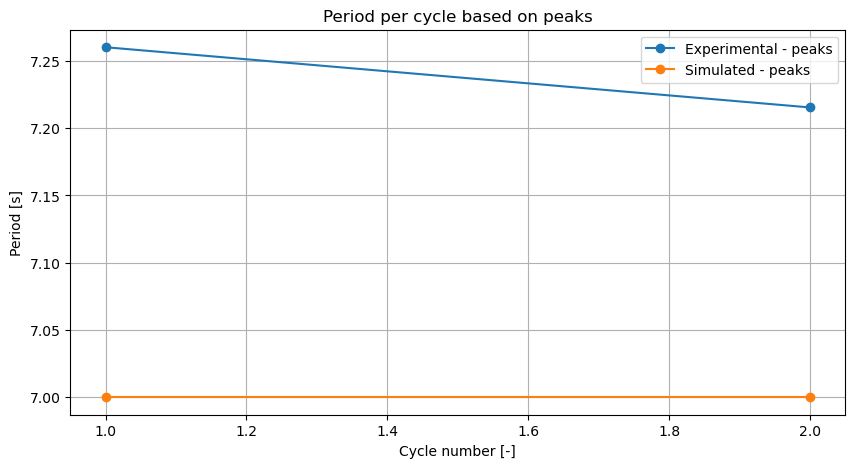

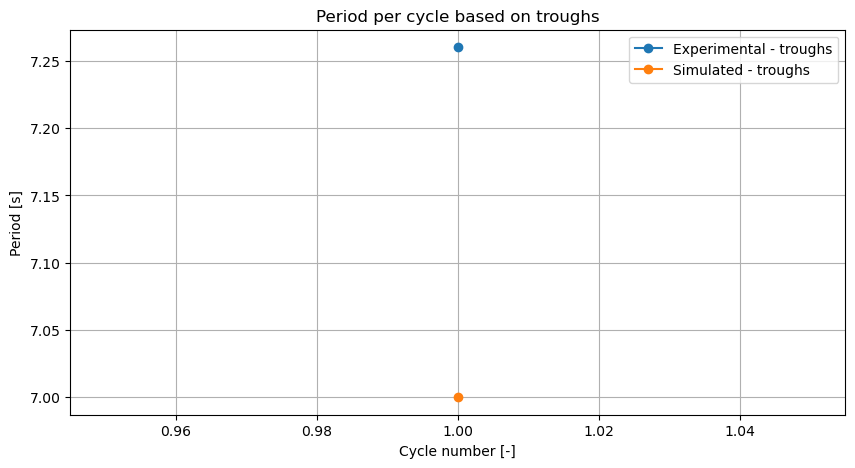

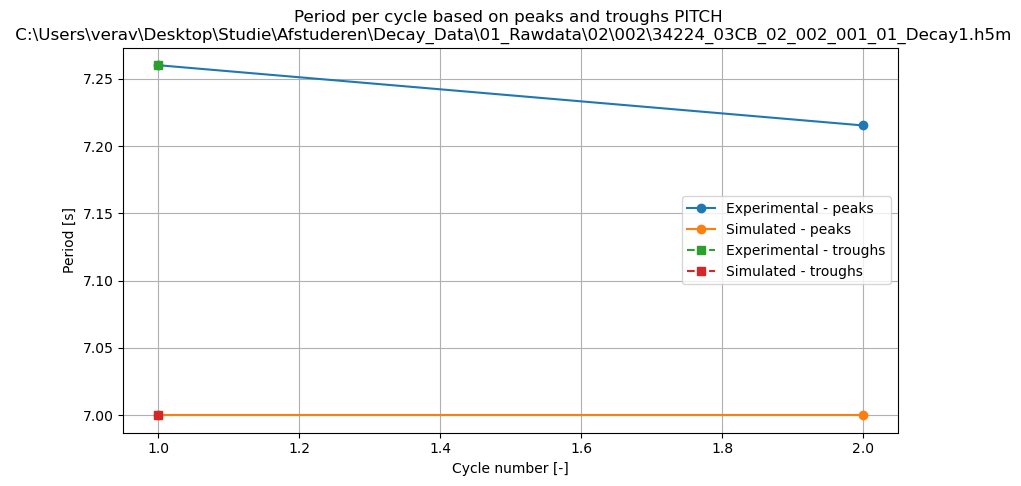

the mean of the experimental periods (peaks) is 7.238 s and the mean of the experimental periods (troughs) is 7.260 s
the mean of the simulated periods (peaks) is 7.000 s and the mean of the simulated periods (troughs) is 7.000 s


In [33]:
plt.figure(figsize=(10, 5))
plt.plot(cycles_peaks, T_exp_peaks_plot, 'o-', label="Experimental - peaks")
plt.plot(cycles_peaks, T_sim_peaks_plot, 'o-', label="Simulated - peaks")
plt.xlabel("Cycle number [-]")
plt.ylabel("Period [s]")
plt.title("Period per cycle based on peaks")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# PLOT 2: periodes uit troughs
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(cycles_troughs, T_exp_troughs_plot, 'o-', label="Experimental - troughs")
plt.plot(cycles_troughs, T_sim_troughs_plot, 'o-', label="Simulated - troughs")
plt.xlabel("Cycle number [-]")
plt.ylabel("Period [s]")
plt.title("Period per cycle based on troughs")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# PLOT 3: alles samen
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(cycles_peaks, T_exp_peaks_plot, 'o-', label="Experimental - peaks")
plt.plot(cycles_peaks, T_sim_peaks_plot, 'o-', label="Simulated - peaks")
plt.plot(cycles_troughs, T_exp_troughs_plot, 's--', label="Experimental - troughs")
plt.plot(cycles_troughs, T_sim_troughs_plot, 's--', label="Simulated - troughs")
plt.xlabel("Cycle number [-]")
plt.ylabel("Period [s]")
plt.title(f"Period per cycle based on peaks and troughs PITCH \n {exp_path.split('/')[-1]}")
plt.grid(True)
plt.legend()
plt.show()


print(f'the mean of the experimental periods (peaks) is {np.mean(T_exp_peaks_plot):.3f} s'
      f' and the mean of the experimental periods (troughs) is {np.mean(T_exp_troughs_plot):.3f} s')
print(f'the mean of the simulated periods (peaks) is {np.mean(T_sim_peaks_plot):.3f} s'
      f' and the mean of the simulated periods (troughs) is {np.mean(T_sim_troughs_plot):.3f} s')